# Wine Quality Classification - Naive Bayes

## Kütüphaneler

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Fonksiyonlar

In [1]:
def load_data():
    # Bu fonksiyon veriyi yüklemek için yazıldı.
    df=load_wine(as_frame=True)
    df_data=df.data
    df_data["target"]=df.target
    return df_data

In [3]:
def explore_data(df):
    # Bu fonksiyon veri keşifi için yazıldı.
    print(df.shape)
    print(df.isnull().sum().sum())
    print(df["target"].value_counts())
    return df.head()

In [4]:
def split_data(df):
    # Bu fonksiyon verinin Train / Test olarak ikiye ayrılmasını sağlar.
    X=df.drop(columns="target")
    y=df["target"]
    X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

In [5]:
def build_model(X_train, y_train):
    # Bu fonksiyon model oluşturma, eğitme ve eğitilen modeli döndürme adımlarını içerir.
    my_model=GaussianNB()
    my_model.fit(X_train, y_train)
    return my_model

In [6]:
def evaluate_model(model, X_test, y_test):
    # Bu fonksiyon oluşturduğumuz model üzerinde tahmin yapmamızı sağlar.
    y_pred=model.predict(X_test)
    print("Accuracy Score", accuracy_score(y_test, y_pred))
    print("Confusion Matrix", confusion_matrix(y_test, y_pred))
    print("Classification Report", classification_report(y_test, y_pred))
    return y_pred

In [7]:
def plot_confusion_matrix(y_test, y_pred):
    # Bu fonksiyon modelimizin confusion matrix değerlerini görselleştirir.
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        cmap="Blues",
        annot=True,
        fmt="d",
        xticklabels=[0,1,2],
        yticklabels=[0,1,2]
    )
    plt.title("Gerçek vs Tahmin (Şarap)")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()

In [8]:
def cross_validate_model(model,X,y):
    # Bu fonksiyon veriyi 5 defa 4 train 1 test olarak ayırır. Her seferinde farklı test grubunu kullanarak modelin başarısının tesadüf mü gerçek mi olduğunu ölçer.
    scores=cross_val_score(model, X, y, cv=5)
    for i, score in enumerate (scores, 1):
        print(f"{i}.fold skoru : {score}")
    print(f"Skorların ortalaması : {scores.mean()}")
    print(f"Skorların standart sapması : {scores.std()}")   

## 3. Çalıştırma ve Sonuçlar

(178, 14)
0
target
1    71
0    59
2    48
Name: count, dtype: int64
Accuracy Score 1.0
Confusion Matrix [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



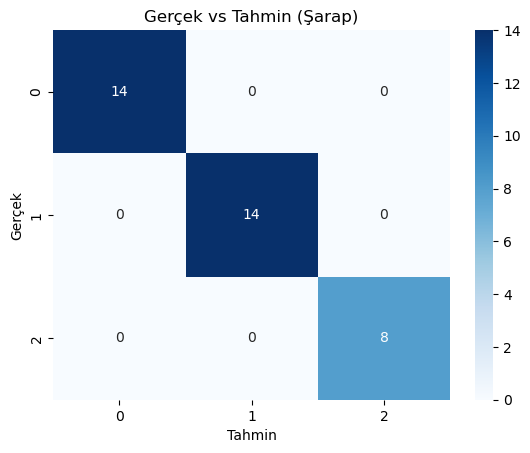

1.fold skoru : 0.9444444444444444
2.fold skoru : 0.9722222222222222
3.fold skoru : 0.9722222222222222
4.fold skoru : 0.9428571428571428
5.fold skoru : 1.0
Skorların ortalaması : 0.9663492063492063
Skorların standart sapması : 0.02113317858457236


In [9]:
if __name__=="__main__":
    df=load_data()
    explore_data(df)
    X_train, X_test, y_train, y_test=split_data(df)
    my_model=build_model(X_train, y_train)
    y_pred=evaluate_model(my_model, X_test, y_test)
    plot_confusion_matrix(y_test, y_pred)
    cross_validate_model(my_model, df.drop(columns="target"), df["target"])